데이터 압축 풀기

In [1]:
!unzip -q /content/data_yolo.zip -d /content/data_yolo

모델 전처리 및 마스킹

## 1. 환경 설정 및 YOLO 모델 전처리

사전 파일 경로 설정

In [2]:
INPUT_DIR = "data_yolo/data_yolo"
OUTPUT_DIR = "dataset_masked"
MODEL_PATH = "yolo_target.pt"
ANGLES_CSV_NAME = "data_angles.csv"

In [3]:
import sys
!{sys.executable} -m pip install ultralytics

from __future__ import annotations
import argparse
import csv
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO

CSV_COLUMNS = ("filename", "yaw_offset")

CONFIDENCE = 0.5
IMAGE_SIZE = 224
BATCH_SIZE = 32
DEVICE = None # YOLO device: 0 for the first GPU or cpu. Default selects automatically.

# Ensure confidence and size are valid
if not 0.0 < CONFIDENCE <= 1.0:
    raise ValueError("CONFIDENCE must be greater than 0 and at most 1")
if IMAGE_SIZE < 1 or BATCH_SIZE < 1:
    raise ValueError("IMAGE_SIZE and BATCH_SIZE must be at least 1")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. YOLO 마스킹 함수

In [4]:
def load_rows(csv_path: Path) -> list[dict[str, str]]:
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    with csv_path.open("r", newline="", encoding="utf-8-sig") as file:
        reader = csv.DictReader(file)
        if tuple(reader.fieldnames or ()) != CSV_COLUMNS:
            raise ValueError(
                f"Invalid CSV header: {reader.fieldnames}. Required: {CSV_COLUMNS}"
            )
        rows = list(reader)

    seen = set()
    for line_number, row in enumerate(rows, start=2):
        filename = row["filename"].strip()
        if not filename:
            raise ValueError(f"Empty filename at CSV line {line_number}")
        if filename in seen:
            raise ValueError(f"Duplicate filename in CSV: {filename}")
        seen.add(filename)

        try:
            float(row["yaw_offset"])
        except ValueError as exc:
            raise ValueError(f"Invalid yaw at CSV line {line_number}") from exc

    return rows


def prepare_source(image_path: Path, image_size: int) -> np.ndarray | None:
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    if image.shape[:2] != (image_size, image_size):
        image = cv2.resize(
            image,
            (image_size, image_size),
            interpolation=cv2.INTER_AREA,
        )

    return image


def make_mask(result, image_size: int) -> np.ndarray | None:
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return None

    confidences = boxes.conf.detach().cpu().numpy()
    best_index = int(np.argmax(confidences))

    coords = boxes.xyxy[best_index].detach().cpu().numpy()
    x1, y1, x2, y2 = np.rint(coords).astype(int)

    x1 = int(np.clip(x1, 0, image_size - 1))
    y1 = int(np.clip(y1, 0, image_size - 1))
    x2 = int(np.clip(x2, 0, image_size - 1))
    y2 = int(np.clip(y2, 0, image_size - 1))

    if x2 <= x1 or y2 <= y1:
        return None

    mask = np.zeros((image_size, image_size, 3), dtype=np.uint8)
    cv2.rectangle(
        mask,
        (x1, y1),
        (x2, y2),
        (255, 255, 255),
        thickness=-1,
    )

    return mask


def write_csv(path: Path, columns: tuple[str, ...], rows: list[list[object]]) -> None:
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(columns)
        writer.writerows(rows)

    temporary_path.replace(path)

## 3. YOLO 마스킹 실행

In [5]:
input_dir = Path(INPUT_DIR)
input_image_dir = input_dir / "images"
output_dir = Path(OUTPUT_DIR)
output_image_dir = output_dir / "images"
model_path = Path(MODEL_PATH)

if not model_path.exists():
    raise FileNotFoundError(f"YOLO model not found: {model_path}")

rows = load_rows(input_dir / ANGLES_CSV_NAME)
output_image_dir.mkdir(parents=True, exist_ok=True)

print(f"Loading YOLO model: {model_path}")
model = YOLO(str(model_path))

valid_rows: list[list[object]] = []
failed_count = 0

print(f"Masking {len(rows)} images...")

for batch_start in range(0, len(rows), BATCH_SIZE):
    batch_rows = rows[batch_start : batch_start + BATCH_SIZE]

    sources = []
    source_rows = []

    for row in batch_rows:
        filename = row["filename"].strip()
        image_path = input_image_dir / filename

        source = prepare_source(image_path, IMAGE_SIZE)

        if source is None:
            failed_count += 1
            continue

        sources.append(source)
        source_rows.append((row, source))

    if not sources:
        continue

    predict_options = {
        "source": sources,
        "conf": CONFIDENCE,
        "verbose": False,
    }

    if DEVICE is not None:
        predict_options["device"] = DEVICE

    results = model.predict(**predict_options)

    for (row, source), result in zip(source_rows, results):
        filename = row["filename"].strip()

        mask = make_mask(result, IMAGE_SIZE)

        if mask is None:
            failed_count += 1
            continue

        output_path = output_image_dir / filename

        if not cv2.imwrite(str(output_path), mask):
            failed_count += 1
            continue

        valid_rows.append([filename, float(row["yaw_offset"])])

    completed = min(batch_start + BATCH_SIZE, len(rows))

    print(
        f"[{completed}/{len(rows)}] "
        f"success={len(valid_rows)}, failed={failed_count}"
    )

write_csv(output_dir / ANGLES_CSV_NAME, CSV_COLUMNS, valid_rows)

print("\nMasking complete")
print(f"  input:   {len(rows)}")
print(f"  success: {len(valid_rows)}")
print(f"  failed:  {failed_count}")
print(f"  output:  {output_dir.resolve()}")

Loading YOLO model: yolo_target.pt
Masking 220 images...
[32/220] success=32, failed=0
[64/220] success=64, failed=0
[96/220] success=96, failed=0
[128/220] success=128, failed=0
[160/220] success=160, failed=0
[192/220] success=192, failed=0
[220/220] success=220, failed=0

Masking complete
  input:   220
  success: 220
  failed:  0
  output:  /content/dataset_masked


/tmp/ipykernel_530/3020782462.py:26: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_530/3020782462.py:26: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_530/3020782462.py:26: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_530/3020782462.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_530/3020782462.py:26: UserWarning: Glyph 53433 (\N{HANGUL SYLLABLE KING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

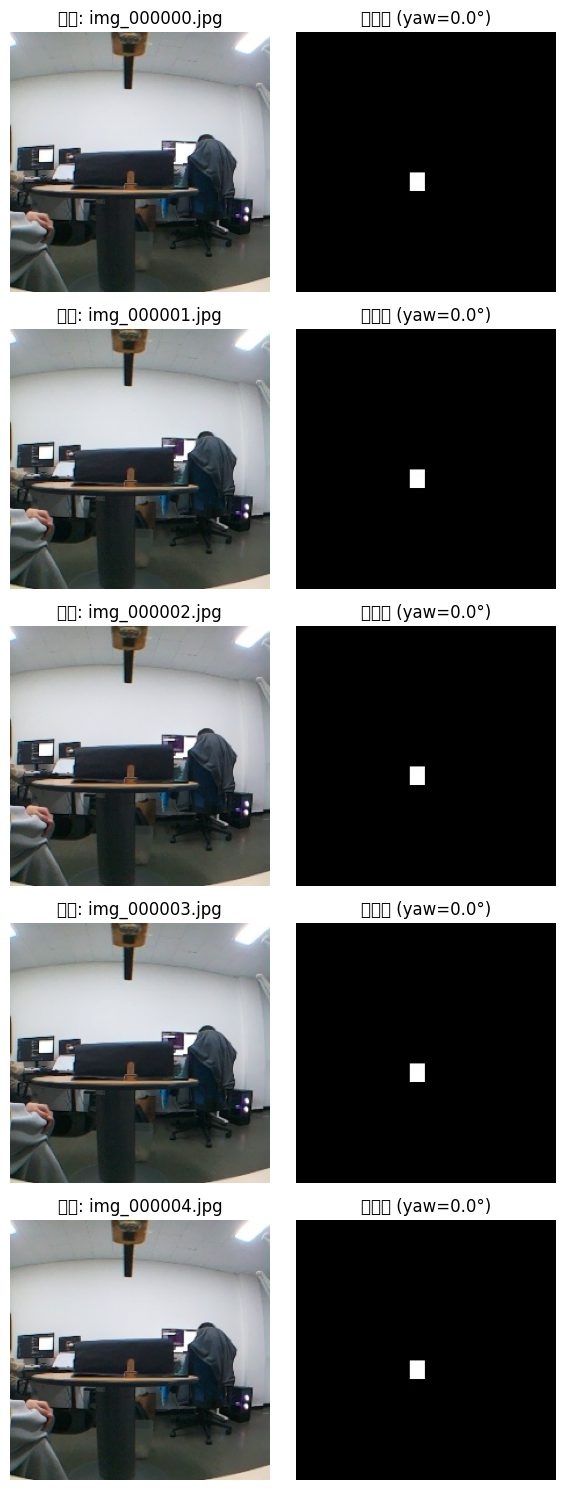

In [6]:
import matplotlib.pyplot as plt

NUM_SAMPLES = 5
sample_rows = valid_rows[:NUM_SAMPLES]

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(6, 3 * len(sample_rows)))

if len(sample_rows) == 1:
    axes = axes.reshape(1, 2)

for row_index, (filename, yaw_offset) in enumerate(sample_rows):
    original = cv2.imread(str(input_image_dir / filename))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    masked = cv2.imread(str(output_image_dir / filename))
    masked = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)

    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title(f"원본: {filename}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(masked)
    axes[row_index, 1].set_title(f"마스킹 (yaw={yaw_offset:.1f}°)")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

모델 학습

## 1. 환경 설정

In [7]:
from __future__ import annotations
import copy
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


# ==========================================
# 1. 설정
# ==========================================

CSV_PATH = "dataset_masked/data_angles.csv"
IMAGE_DIR = "dataset_masked/images"

OUTPUT_DIR = "yaw_cnn_output"
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_yaw_cnn.pth")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_RATIO = 0.2
PATIENCE = 5
RANDOM_SEED = 42
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cpu" and torch.backends.mps.is_available():
    device = torch.device("mps")

print(f"사용 장치: {device}")

사용 장치: cpu


## 2. YawDataset 사용자 정의 데이터셋 클래스

In [8]:
class YawDataset(Dataset):
    def __init__(self, filenames, labels, image_dir, transform=None):
        self.filenames = list(filenames)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        image_path = os.path.join(self.image_dir, self.filenames[index])

        # 마스크 이미지는 흑백 1채널로 사용
        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        # 출력 형태
        label = torch.tensor([self.labels[index]], dtype=torch.float32)

        return image, label

## 3. YawCNN 모델 아키텍처

In [9]:
class YawCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # 정규화된 yaw 범위 0~1
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

## 4. 데이터 준비 및 DataLoader 생성

In [10]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV 파일이 없습니다: {CSV_PATH}")

if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(f"이미지 폴더가 없습니다: {IMAGE_DIR}")

df = pd.read_csv(CSV_PATH)

required_columns = {"filename", "yaw_offset"}
if not required_columns.issubset(df.columns):
    raise ValueError("CSV에는 filename, yaw_offset 열이 필요합니다.")

if len(df) == 0:
    raise ValueError(
        "CSV에 학습할 데이터가 없습니다. "
        "마스킹 전처리 결과 success가 0인지 먼저 확인하세요."
    )

if df["filename"].duplicated().any():
    raise ValueError("CSV에 중복된 filename이 있습니다.")

missing_images = [
    name
    for name in df["filename"]
    if not os.path.exists(os.path.join(IMAGE_DIR, name))
]

if missing_images:
    raise FileNotFoundError(
        f"CSV에는 있지만 이미지 폴더에 없는 파일이 {len(missing_images)}개 있습니다. "
        f"예시: {missing_images[:5]}"
    )

filenames = df["filename"].values
yaws = df["yaw_offset"].astype(np.float32).values

yaw_min = float(yaws.min())
yaw_max = float(yaws.max())

if yaw_min == yaw_max:
    raise ValueError("Yaw 라벨 값이 모두 같습니다. 회귀 학습이 불가능합니다.")

# yaw_offset을 0~1 범위로 정규화
normalized_yaws = (yaws - yaw_min) / (yaw_max - yaw_min)

# 각 yaw 값의 개수가 너무 적으면 stratify가 실패할 수 있으므로 안전하게 처리
yaw_counts = pd.Series(yaws).value_counts()
use_stratify = yaw_counts.min() >= 2

stratify_labels = yaws if use_stratify else None

train_files, val_files, train_labels, val_labels = train_test_split(
    filenames,
    normalized_yaws,
    test_size=VALIDATION_RATIO,
    random_state=RANDOM_SEED,
    stratify=stratify_labels,
)

transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]
)

train_dataset = YawDataset(
    filenames=train_files,
    labels=train_labels,
    image_dir=IMAGE_DIR,
    transform=transform,
)

val_dataset = YawDataset(
    filenames=val_files,
    labels=val_labels,
    image_dir=IMAGE_DIR,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"전체 데이터: {len(df)}장")
print(f"학습/검증: {len(train_dataset)}장 / {len(val_dataset)}장")
print(f"Yaw 범위: {yaw_min:.1f}° ~ {yaw_max:.1f}°")

if use_stratify:
    print("데이터 분할: yaw_offset 기준 층화 분할 사용")
else:
    print("데이터 분할: 일반 랜덤 분할 사용")

전체 데이터: 220장
학습/검증: 176장 / 44장
Yaw 범위: -18.0° ~ 18.0°
데이터 분할: yaw_offset 기준 층화 분할 사용


## 5. 모델, 손실 함수, Optimizer 및 스케줄러 설정

In [11]:
model = YawCNN().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

parameter_count = sum(p.numel() for p in model.parameters())
print(f"모델 파라미터: {parameter_count:,}개")
print("\n학습 시작")

모델 파라미터: 228,353개

학습 시작


## 6. 모델 학습 및 검증 루프

In [12]:
best_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(EPOCHS):
    start_time = time.time()

    # ------------------------------
    # 학습
    # ------------------------------
    model.train()
    train_loss_sum = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predictions = model(images)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

    train_loss = train_loss_sum / len(train_dataset)

    # ------------------------------
    # 검증
    # ------------------------------
    model.eval()
    val_loss_sum = 0.0
    val_error_sum = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images)
            loss = criterion(predictions, labels)

            val_loss_sum += loss.item() * images.size(0)

            # 정규화된 값을 실제 각도로 복원해서 MAE 계산
            predicted_degrees = predictions * (yaw_max - yaw_min) + yaw_min
            label_degrees = labels * (yaw_max - yaw_min) + yaw_min

            val_error_sum += torch.abs(
                predicted_degrees - label_degrees
            ).sum().item()

    val_loss = val_loss_sum / len(val_dataset)
    val_mae = val_error_sum / len(val_dataset)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch + 1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Yaw MAE: {val_mae:.3f}° | "
        f"Time: {time.time() - start_time:.1f}s"
    )

    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("  최고 모델 갱신")
    else:
        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("조기 종료")
            break

Epoch 001/50 | Train Loss: 0.088202 | Val Loss: 0.086147 | Yaw MAE: 9.240° | Time: 20.9s
  최고 모델 갱신
Epoch 002/50 | Train Loss: 0.084551 | Val Loss: 0.074166 | Yaw MAE: 8.478° | Time: 14.1s
  최고 모델 갱신
Epoch 003/50 | Train Loss: 0.057005 | Val Loss: 0.025538 | Yaw MAE: 4.667° | Time: 11.0s
  최고 모델 갱신
Epoch 004/50 | Train Loss: 0.031080 | Val Loss: 0.024281 | Yaw MAE: 4.611° | Time: 10.9s
  최고 모델 갱신
Epoch 005/50 | Train Loss: 0.025950 | Val Loss: 0.027378 | Yaw MAE: 5.040° | Time: 12.7s
Epoch 006/50 | Train Loss: 0.021139 | Val Loss: 0.019832 | Yaw MAE: 4.098° | Time: 10.8s
  최고 모델 갱신
Epoch 007/50 | Train Loss: 0.015963 | Val Loss: 0.015043 | Yaw MAE: 3.447° | Time: 9.9s
  최고 모델 갱신
Epoch 008/50 | Train Loss: 0.014891 | Val Loss: 0.012313 | Yaw MAE: 3.357° | Time: 10.9s
  최고 모델 갱신
Epoch 009/50 | Train Loss: 0.013022 | Val Loss: 0.011066 | Yaw MAE: 3.172° | Time: 11.6s
  최고 모델 갱신
Epoch 010/50 | Train Loss: 0.010442 | Val Loss: 0.010211 | Yaw MAE: 2.977° | Time: 11.9s
  최고 모델 갱신
Epoch 011/50

## 7. 최고 모델 저장

In [13]:
model.load_state_dict(best_weights)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "image_size": IMG_SIZE,
        "yaw_min": yaw_min,
        "yaw_max": yaw_max,
        "model_name": "YawCNN",
    },
    MODEL_SAVE_PATH,
)

print("\n학습 완료")
print(f"최고 검증 Loss: {best_loss:.6f}")
print(f"모델 저장: {MODEL_SAVE_PATH}")


학습 완료
최고 검증 Loss: 0.000240
모델 저장: yaw_cnn_output/best_yaw_cnn.pth
